# Part 1: CNN Model Baseline - Performance & Testing

## Overview
In this notebook, we will:
1. Train a simple CNN model on an ADAS (Advanced Driver Assistance Systems) dataset
2. Log key performance metrics: accuracy, inference time, model size, parameters
3. Understand the relationship between model complexity and performance
4. Establish a baseline for robustness testing

## Key Concepts
- **Time Complexity**: How inference time grows with input size
- **Model Size vs Performance**: The tradeoff between model complexity and accuracy
- **Baseline Metrics**: Essential measurements for ML model evaluation

## Step 1: Import Libraries & Setup

In [4]:
import os
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18

# Progress bar
from tqdm import tqdm

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## Step 2: Device Configuration

In [5]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("Running on CPU - training may be slower")

Using device: cuda
GPU: NVIDIA GeForce GTX 1050 Ti with Max-Q Design
CUDA Version: 12.1


## Step 3: Load Dataset

In [6]:
# Dataset paths
DATASET_PATH = r"C:\Users\Lucifer\OneDrive\BITS\AI_Quality_Engineering\dataset"
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "val")
TEST_PATH = os.path.join(DATASET_PATH, "test")

print(f"📁 Dataset path: {DATASET_PATH}")

📁 Dataset path: C:\Users\Lucifer\OneDrive\BITS\AI_Quality_Engineering\dataset


In [7]:
# Data transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize to fixed size
    transforms.ToTensor(),           # Convert to tensor (0-1 range)
    transforms.Normalize(            # Normalize with ImageNet stats(Mean and std computed over millions of images)
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Data transformations defined")

✅ Data transformations defined


In [8]:
# Load datasets
print("Loading datasets...")
train_dataset = ImageFolder(TRAIN_PATH, transform=transform)
val_dataset = ImageFolder(VAL_PATH, transform=transform)
test_dataset = ImageFolder(TEST_PATH, transform=transform)

print(f"✅ Train samples: {len(train_dataset)}")
print(f"✅ Val samples: {len(val_dataset)}")
print(f"✅ Test samples: {len(test_dataset)}")

# Class names
class_names = train_dataset.classes
num_classes = len(class_names)
print(f"\n📚 Classes ({num_classes}): {', '.join(class_names)}")

Loading datasets...


✅ Train samples: 796
✅ Val samples: 234
✅ Test samples: 117

📚 Classes (7): animal, name_board, pedestrian, pothole, road_sign, speed_breaker, vehicle


In [9]:
# Data loaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ Data loaders created with batch size: {BATCH_SIZE}")

✅ Data loaders created with batch size: 16


## Step 4: Create Model Architecture

In [10]:
# Create model
model = resnet18(pretrained=True)  # Use pre-trained weights
model.fc = nn.Linear(model.fc.in_features, num_classes)  # Modify final layer
model = model.to(device)

print("✅ ResNet-18 model created")
print(f"   Modified final layer to output {num_classes} classes")

c:\Users\Lucifer\anaconda3\envs\venv_ai_quality\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Lucifer\anaconda3\envs\venv_ai_quality\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ ResNet-18 model created
   Modified final layer to output 7 classes


In [11]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Architecture Overview

We use **ResNet-18**, a pre-trained convolutional neural network:
- Input size: 128×128×3 (RGB images)
- Output: 7 classes (ADAS categories)
- Pre-trained on ImageNet for better feature extraction
- Lightweight: good balance between accuracy and speed

## Step 5: Analyze Model Complexity

In [12]:
def count_parameters(model):
    """Count total trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_model_size_mb(model):
    """Get model size in MB"""
    torch.save(model.state_dict(), "temp_model.pth")
    size_mb = os.path.getsize("temp_model.pth") / (1024 * 1024)
    os.remove("temp_model.pth")
    return size_mb

total_params = count_parameters(model)
model_size = get_model_size_mb(model)

print(f"📊 Model Statistics:")
print(f"  Total Parameters: {total_params:,}")
print(f"  Model Size: {model_size:.2f} MB")
print(f"  Average parameter size: {(model_size * 1024 * 1024 / total_params):.2f} bytes")

# Store for later
metrics = {
    'total_parameters': total_params,
    'model_size_mb': model_size
}

📊 Model Statistics:
  Total Parameters: 11,180,103
  Model Size: 42.72 MB
  Average parameter size: 4.01 bytes


## Step 6: Setup Training Configuration

In [13]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("✅ Loss function: CrossEntropyLoss")
print("✅ Optimizer: Adam (lr=0.01)")

✅ Loss function: CrossEntropyLoss
✅ Optimizer: Adam (lr=0.01)


## Step 7: Define Training & Evaluation Functions

In [14]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    start_time = time.time()
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_time = time.time() - start_time
    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy, epoch_time

print("✅ train_epoch() defined")

✅ train_epoch() defined


In [15]:
def evaluate(model, loader, criterion, device):
    """Evaluate on validation/test set"""
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    
    start_time = time.time()
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    eval_time = time.time() - start_time
    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy, eval_time

print("✅ evaluate() defined")

✅ evaluate() defined


## Step 8: Train the Model

In [16]:
NUM_EPOCHS = 30
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'train_time': [],
    'val_time': []
}

print(f"Starting training for {NUM_EPOCHS} epochs...\n")
overall_start = time.time()

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_acc, train_time = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_acc, val_time = evaluate(
        model, val_loader, criterion, device
    )
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['train_time'].append(train_time)
    history['val_time'].append(val_time)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"  Time: Train {train_time:.2f}s | Val {val_time:.2f}s\n")

overall_time = time.time() - overall_start
print(f"✅ Training completed in {overall_time:.2f} seconds")

metrics['total_training_time'] = overall_time

Starting training for 30 epochs...



Epoch [1/30]
  Train Loss: 2.2816 | Train Acc: 53.02%
  Val Loss:   1.2193 | Val Acc: 69.23%
  Time: Train 19.57s | Val 2.57s



Epoch [2/30]
  Train Loss: 1.2110 | Train Acc: 65.08%
  Val Loss:   1.0132 | Val Acc: 70.09%
  Time: Train 17.49s | Val 4.69s



Epoch [3/30]
  Train Loss: 1.0261 | Train Acc: 69.72%
  Val Loss:   0.8858 | Val Acc: 74.79%
  Time: Train 16.41s | Val 4.14s



Epoch [4/30]
  Train Loss: 0.8926 | Train Acc: 70.85%
  Val Loss:   0.7531 | Val Acc: 74.36%
  Time: Train 14.59s | Val 3.48s



...

Epoch [26/30]
  Train Loss: 0.2625 | Train Acc: 90.33%
  Val Loss:   0.4411 | Val Acc: 84.62%
  Time: Train 21.00s | Val 2.41s



Epoch [27/30]
  Train Loss: 0.2539 | Train Acc: 91.21%
  Val Loss:   0.5916 | Val Acc: 74.36%
  Time: Train 11.28s | Val 2.34s



Epoch [28/30]
  Train Loss: 0.2908 | Train Acc: 89.32%
  Val Loss:   0.3083 | Val Acc: 88.46%
  Time: Train 11.00s | Val 2.45s



Epoch [29/30]
  Train Loss: 0.2439 | Train Acc: 90.70%
  Val Loss:   0.6235 | Val Acc: 78.21%
  Time: Train 11.45s | Val 2.58s



Epoch [30/30]
  Train Loss: 0.3696 | Train Acc: 88.07%
  Val Loss:   0.4905 | Val Acc: 81.20%
  Time: Train 12.00s | Val 2.40s

✅ Training completed in 606.49 seconds


## Step 9: Test Evaluation

In [17]:
# Test evaluation
test_loss, test_acc, test_time = evaluate(model, test_loader, criterion, device)

# Calculate per-image inference time
num_test_samples = len(test_dataset)
avg_inference_time = (test_time / num_test_samples) * 1000  # in milliseconds

print("\n" + "="*60)
print("📊 TEST SET PERFORMANCE")
print("="*60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Total Inference Time: {test_time:.2f} seconds")
print(f"Avg Inference Time per Image: {avg_inference_time:.4f} ms")
print("="*60 + "\n")

# Update metrics
metrics['test_accuracy'] = test_acc
metrics['total_inference_time'] = test_time
metrics['avg_inference_time_ms'] = avg_inference_time


📊 TEST SET PERFORMANCE
Test Loss: 0.4046
Test Accuracy: 82.05%
Total Inference Time: 1.33 seconds
Avg Inference Time per Image: 11.3566 ms



## Step 10: Visualize Training History

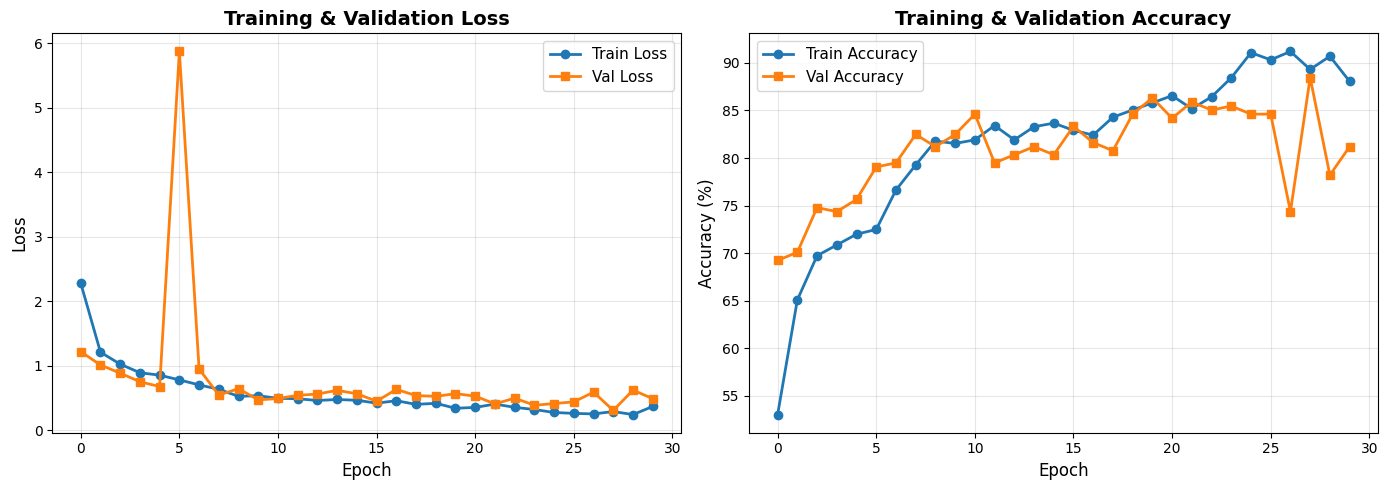

✅ Training curves saved as 'training_curves.png'


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training curves saved as 'training_curves.png'")

## Step 11: Final Summary Report

In [19]:
print("\n" + "="*70)
print("🎯 BASELINE MODEL PERFORMANCE REPORT")
print("="*70)

print("\n📈 Accuracy Metrics:")
print(f"  Train Accuracy (final epoch): {history['train_acc'][-1]:.2f}%")
print(f"  Val Accuracy (final epoch):   {history['val_acc'][-1]:.2f}%")
print(f"  Test Accuracy:                {metrics['test_accuracy']:.2f}%")

print("\n⏱️  Time Metrics:")
print(f"  Total Training Time:          {metrics['total_training_time']:.2f} seconds")
print(f"  Total Inference Time:         {metrics['total_inference_time']:.2f} seconds")
print(f"  Avg Inference per Image:      {metrics['avg_inference_time_ms']:.4f} ms")

print("\n📊 Model Complexity:")
print(f"  Total Parameters:             {metrics['total_parameters']:,}")
print(f"  Model Size:                   {metrics['model_size_mb']:.2f} MB")

# Analysis
train_val_gap = history['train_acc'][-1] - history['val_acc'][-1]

print("\n🔑 Key Observations:")
print(f"  Train-Val Accuracy Gap:       {train_val_gap:.2f}%")

if train_val_gap > 10:
    print("  ⚠️  High overfitting detected (Train >> Val accuracy)")
elif train_val_gap > 5:
    print("  ⚠️  Some overfitting detected")
else:
    print("  ✅ Good generalization (Train and Val accuracy are close)")

print("\n💡 This baseline will be used for:")
print("  • Overfitting detection in Part 2")
print("  • Robustness testing in Part 3")
print("  • Comparing with regularization techniques")

print("\n" + "="*70)


🎯 BASELINE MODEL PERFORMANCE REPORT

📈 Accuracy Metrics:
  Train Accuracy (final epoch): 88.07%
  Val Accuracy (final epoch):   81.20%
  Test Accuracy:                82.05%

⏱️  Time Metrics:
  Total Training Time:          606.49 seconds
  Total Inference Time:         1.33 seconds
  Avg Inference per Image:      11.3566 ms

📊 Model Complexity:
  Total Parameters:             11,180,103
  Model Size:                   42.72 MB

🔑 Key Observations:
  Train-Val Accuracy Gap:       6.87%
  ⚠️  Some overfitting detected

💡 This baseline will be used for:
  • Overfitting detection in Part 2
  • Robustness testing in Part 3
  • Comparing with regularization techniques

